# 00 — Exploración do Corpus

Análise exploratorio de `data/raw/corpus_clean.jsonl` para caracterizar o corpus. Obxectivo: extraer os indicadores que describen o corpus no TFG.

## 0. Setup

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

CORPUS  = Path('..') / 'data' / '02_intermediate' / 'corpus_clean.jsonl'
FIGURES = Path('..') / 'data' / '08_reporting' / 'eda' / 'figures'
TABLES  = Path('..') / 'data' / '08_reporting' / 'eda' / 'tables'

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

FAMILY_COLORS = {
    'LEGISLATIVE': '#4C72B0',
    'JUDICIAL':    '#DD8452',
    'POLICY':      '#55A868',
    'OTHER':       '#C44E52',
}

In [2]:
records = []
with open(CORPUS, encoding='utf-8') as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)
df['text_len'] = df['text'].str.len()

def parse_year(date_str):
    if not date_str or len(date_str) < 10:
        return None
    try:
        return int(date_str[6:10])
    except (ValueError, IndexError):
        return None

df['year'] = df['date'].apply(parse_year)

print(f'Total documentos: {len(df):,}')
df.head(2)

Total documentos: 40,181


,doc_id,celex,title,form,family,author,date,date_type,latest,pages,url,text,text_len,year
0,0,32012R0386,Regulation (EU) No 386/2012 of the European Pa...,Regulation,LEGISLATIVE,"European Parliament, Council of the European U...",19/04/2012,,,6,https://eur-lex.europa.eu/legal-content/AUTO/?...,REGULATION (EU) No 386/2012 OF THE EUROPEAN PA...,25415,2012.0
1,1,32004L0048,DIRECTIVE 2004/48/EC OF THE EUROPEAN PARLIAMEN...,Directive,LEGISLATIVE,"European Parliament, Council of the European U...",29/04/2004,,30/04/2004,42,https://eur-lex.europa.eu/legal-content/AUTO/?...,DIRECTIVE 2004/48/EC OF THE EUROPEAN PARLIAMEN...,38570,2004.0


## 1. Corpus de un vistazo

In [3]:
years_valid = df['year'].dropna().astype(int)
nonzero     = df[df['text_len'] > 0]['text_len']

glance = pd.DataFrame({
    'Indicador': [
        'Total documentos',
        'Familias distintas',
        'Tipos de acto (forms) distintos',
        'Rango temporal',
        'Documentos sen data válida',
        'Lonxitude mediana do texto (palabras aprox.)',
        'Lonxitude media do texto (palabras aprox.)',
        'Documentos con texto baleiro',
    ],
    'Valor': [
        f'{len(df):,}',
        str(df['family'].nunique()),
        str(df['form'].nunique()),
        f'{years_valid.min()} – {years_valid.max()}',
        str(df['year'].isna().sum()),
        f'{int(nonzero.median() / 5):,}',
        f'{int(nonzero.mean() / 5):,}',
        str((df['text_len'] == 0).sum()),
    ]
})
display(glance)
glance.to_csv(TABLES / 'corpus_glance.csv', index=False)

,Indicador,Valor
0,Total documentos,"40,181"
1,Familias distintas,4
2,Tipos de acto (forms) distintos,207
3,Rango temporal,1957 – 2025
4,Documentos sen data válida,13
5,Lonxitude mediana do texto (palabras aprox.),607
6,Lonxitude media do texto (palabras aprox.),"9,980"
7,Documentos con texto baleiro,71


## 2. Distribución por familia e tipo de acto

In [4]:
fam_table = df['family'].value_counts().reset_index()
fam_table.columns = ['familia', 'documentos']
fam_table['porcentaxe'] = (fam_table['documentos'] / len(df) * 100).round(1)
display(fam_table)
fam_table.to_csv(TABLES / 'family_distribution.csv', index=False)

,familia,documentos,porcentaxe
0,JUDICIAL,20253,50.4
1,POLICY,8005,19.9
2,LEGISLATIVE,7246,18.0
3,OTHER,4677,11.6


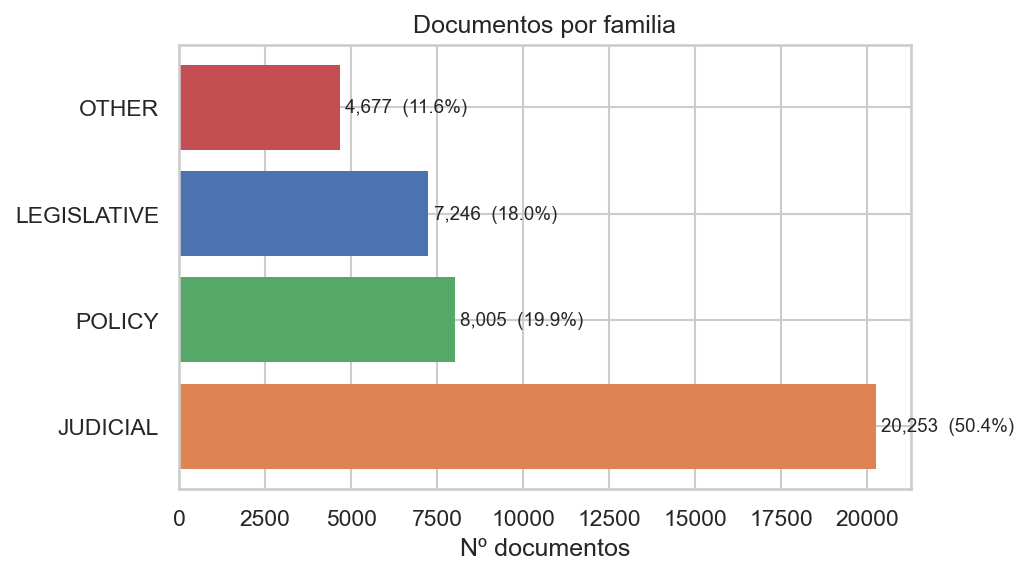

In [5]:
fam_counts = df['family'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(
    fam_counts.index, fam_counts.values,
    color=[FAMILY_COLORS[f] for f in fam_counts.index], edgecolor='none'
)
for bar, val in zip(bars, fam_counts.values):
    ax.text(val + 150, bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Nº documentos')
ax.set_title('Documentos por familia')
plt.tight_layout()
plt.savefig(FIGURES / 'eda_families.pdf')
plt.savefig(FIGURES / 'eda_families.png')
plt.show()

In [6]:
print('=== Top 5 tipos de acto por familia ===')
for fam in ['LEGISLATIVE', 'JUDICIAL', 'POLICY', 'OTHER']:
    total_fam = (df['family'] == fam).sum()
    top = df[df['family'] == fam]['form'].value_counts().head(5)
    print(f'\n{fam} ({total_fam:,} docs):')
    for form, cnt in top.items():
        print(f'  {form:<45} {cnt:>5,}  ({cnt/total_fam*100:.1f}%)')

=== Top 5 tipos de acto por familia ===

LEGISLATIVE (7,246 docs):
  Implementing regulation                       2,573  (35.5%)
  Decision                                      1,452  (20.0%)
  Regulation                                      531  (7.3%)
  Consolidated text                               405  (5.6%)
  International agreement                         352  (4.9%)

JUDICIAL (20,253 docs):
  Judicial information                          11,517  (56.9%)
  Judgment                                      3,971  (19.6%)
  Information                                   2,418  (11.9%)
  Order                                           873  (4.3%)
  Opinion of the Advocate General                 808  (4.0%)

POLICY (8,005 docs):
  Written question                              1,522  (19.0%)
  Communication                                 1,430  (17.9%)
  Staff working document                          846  (10.6%)
  Opinion                                         684  (8.5%)
  Report 

## 3. Lonxitude do texto

In [7]:
percs = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
len_stats = df['text_len'].quantile(percs).rename('chars').to_frame()
len_stats.index = [f'p{int(p*100)}' for p in percs]
len_stats['chars']             = len_stats['chars'].astype(int)
len_stats['palabras (aprox.)'] = (len_stats['chars'] / 5).astype(int)
display(len_stats)
len_stats.to_csv(TABLES / 'length_percentiles_global.csv')

print(f"\nDocumentos baleiros (len=0): {(df['text_len'] == 0).sum()}")
print(f"Moi curtos (<500 chars):     {(df['text_len'] < 500).sum()}")
print(f"Moi longos (>500k chars):    {(df['text_len'] > 500_000).sum()}")

,chars,palabras (aprox.)
p10,1086,217
p25,1497,299
p50,3030,606
p75,25857,5171
p90,88304,17660
p95,210277,42055
p99,716853,143370



Documentos baleiros (len=0): 71
Moi curtos (<500 chars):     731
Moi longos (>500k chars):    662


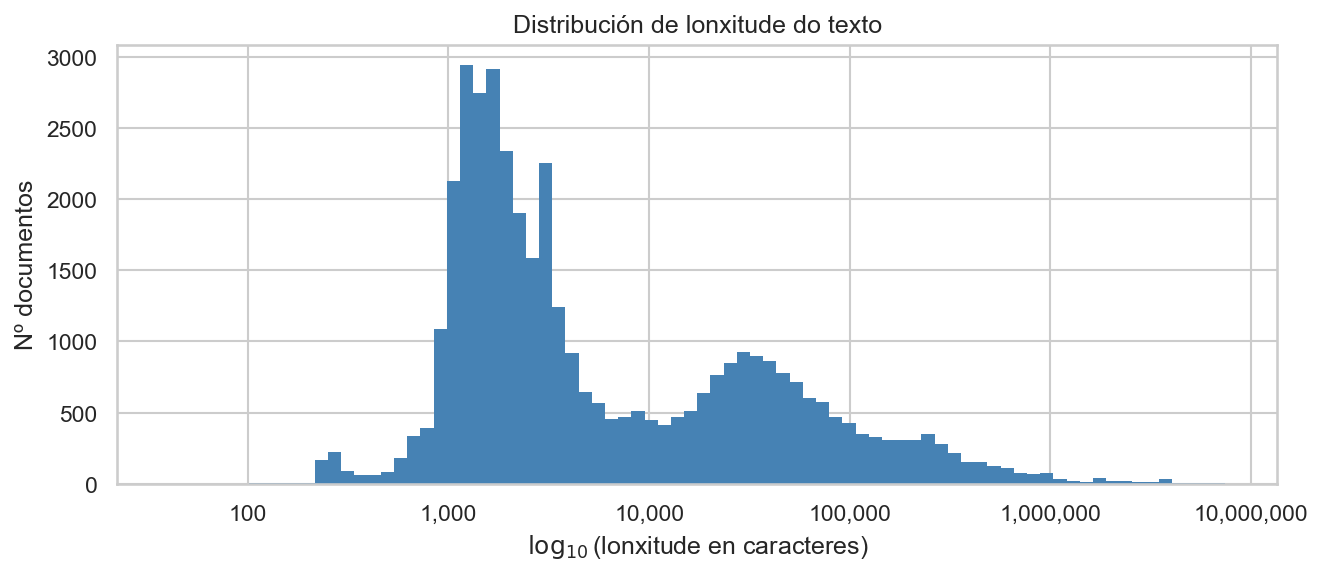

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
nonzero = df.loc[df['text_len'] > 0, 'text_len']
ax.hist(np.log10(nonzero), bins=80, color='steelblue', edgecolor='none')
ax.set_xlabel(r'$\log_{10}$(lonxitude en caracteres)')
ax.set_ylabel('Nº documentos')
ax.set_title('Distribución de lonxitude do texto')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{10**x:,.0f}'))
plt.tight_layout()
plt.savefig(FIGURES / 'eda_length_distribution.pdf')
plt.savefig(FIGURES / 'eda_length_distribution.png')
plt.show()

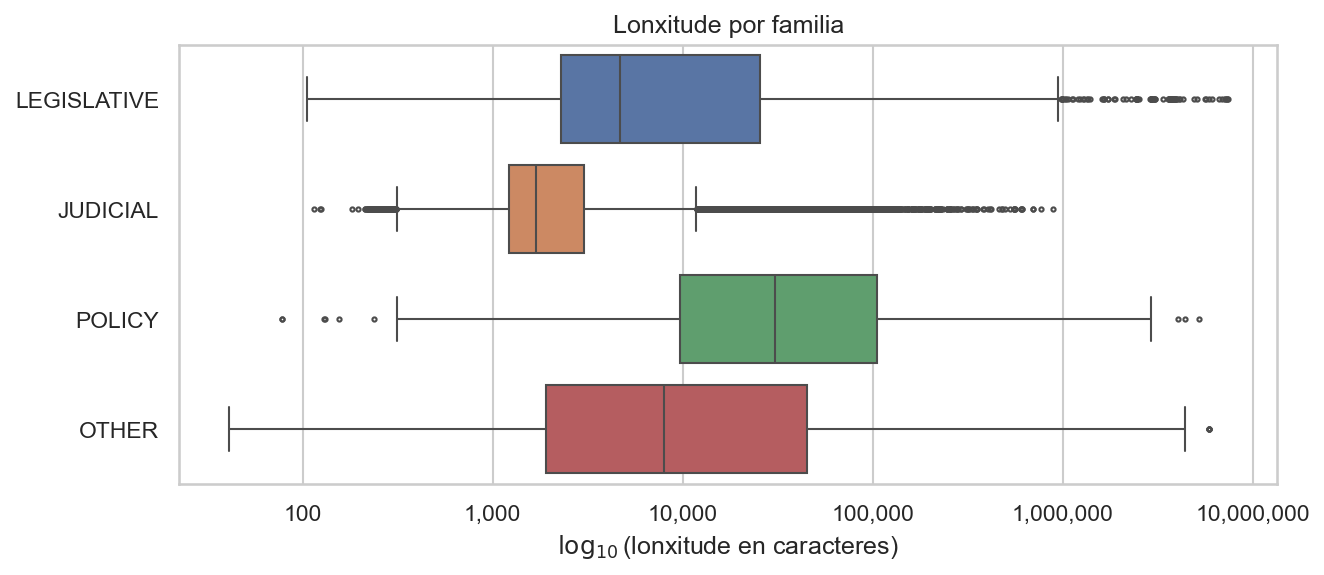

,mediana_palabras,media_palabras,std_palabras
family,,,
JUDICIAL,336,1850,5988
LEGISLATIVE,938,15624,85173
OTHER,1588,15599,63401
POLICY,6132,22241,47695


In [9]:
plot_df = df[df['text_len'] > 0].copy()
order = ['LEGISLATIVE', 'JUDICIAL', 'POLICY', 'OTHER']

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(
    data=plot_df, x=np.log10(plot_df['text_len']), y='family', order=order,
    hue='family', palette=FAMILY_COLORS, legend=False, ax=ax, fliersize=2
)
ax.set_xlabel(r'$\log_{10}$(lonxitude en caracteres)')
ax.set_ylabel('')
ax.set_title('Lonxitude por familia')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{10**x:,.0f}'))
plt.tight_layout()
plt.savefig(FIGURES / 'eda_length_by_family.pdf')
plt.savefig(FIGURES / 'eda_length_by_family.png')
plt.show()

stats = df[df['text_len'] > 0].groupby('family')['text_len'].agg(
    mediana_palabras=lambda x: int(x.median() / 5),
    media_palabras=lambda x:   int(x.mean()   / 5),
    std_palabras=lambda x:     int(x.std()    / 5),
)
display(stats)
stats.to_csv(TABLES / 'length_stats_by_family.csv')

## 4. Distribución temporal

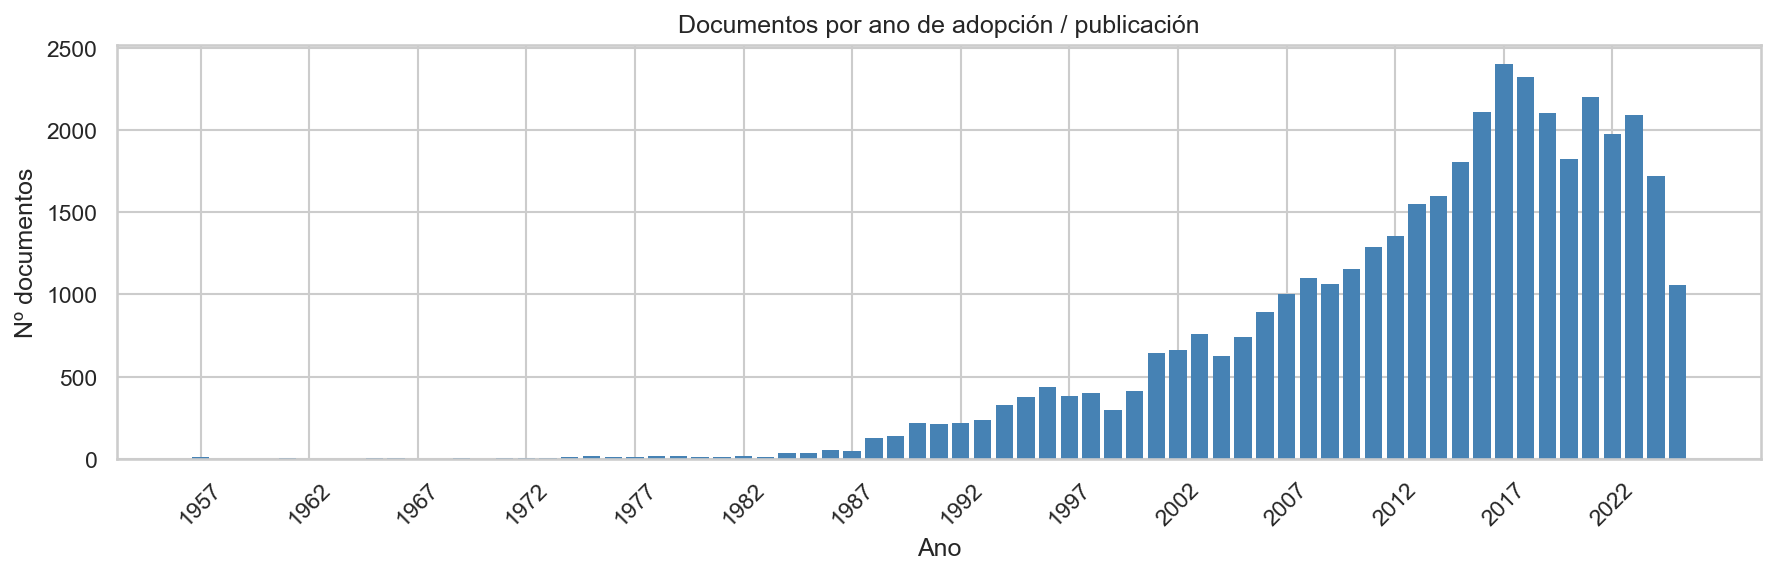

Rango: 1957 – 2025
Sen data válida: 13


In [10]:
year_counts = df['year'].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='none', width=0.8)
ax.set_xlabel('Ano')
ax.set_ylabel('Nº documentos')
ax.set_title('Documentos por ano de adopción / publicación')
ax.set_xticks(range(int(year_counts.index.min()), int(year_counts.index.max()) + 1, 5))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES / 'eda_temporal.pdf')
plt.savefig(FIGURES / 'eda_temporal.png')
plt.show()

print(f"Rango: {int(year_counts.index.min())} – {int(year_counts.index.max())}")
print(f"Sen data válida: {df['year'].isna().sum()}")
year_counts.reset_index().rename(columns={'year': 'ano', 'count': 'documentos'}).to_csv(
    TABLES / 'temporal_distribution.csv', index=False
)

## 5. Orixe institucional

Qué institucións e organismos da UE producen os documentos do corpus.

In [11]:
auth_table = df['author'].value_counts().head(15).reset_index()
auth_table.columns = ['autor', 'documentos']
auth_table['pct'] = (auth_table['documentos'] / len(df) * 100).round(1)
display(auth_table)
auth_table.to_csv(TABLES / 'author_distribution.csv', index=False)

,autor,documentos,pct
0,General Court,14231,35.4
1,European Commission,6533,16.3
2,Court of Justice,5321,13.2
3,Court of First Instance,2075,5.2
4,Council of the European Union,1693,4.2
5,"European Commission, Directorate-General for A...",1226,3.1
6,European Economic and Social Committee,942,2.3
7,"European Parliament,Not available",650,1.6
8,Not available,500,1.2
9,European Parliament,432,1.1


## 6. Familia JUDICIAL: avisos vs. xurisprudencia sustantiva

Dentro de JUDICIAL hai dous subtipos moi distintos en lonxitude e utilidade para RAG.

In [12]:
judicial = df[df['family'] == 'JUDICIAL'].copy()
judicial['subtype'] = judicial['form'].apply(
    lambda f: 'Aviso procesual' if f == 'Judicial information' else 'Xurisprudencia sustantiva'
)

jud_summary = judicial.groupby('subtype').agg(
    documentos=('text_len', 'count'),
    p10=('text_len', lambda x: int(x.quantile(0.10))),
    p25=('text_len', lambda x: int(x.quantile(0.25))),
    p50=('text_len', lambda x: int(x.quantile(0.50))),
    p90=('text_len', lambda x: int(x.quantile(0.90))),
    p99=('text_len', lambda x: int(x.quantile(0.99))),
)
display(jud_summary)
jud_summary.to_csv(TABLES / 'judicial_subtype_lengths.csv')

print('\nForms en Xurisprudencia sustantiva:')
display(
    judicial[judicial['subtype'] == 'Xurisprudencia sustantiva']['form']
    .value_counts().head(10)
)

,documentos,p10,p25,p50,p90,p99
subtype,,,,,,
Aviso procesual,11517,874,1096,1321,2226,4952
Xurisprudencia sustantiva,8736,1479,2083,3157,54290,182819



Forms en Xurisprudencia sustantiva:


form
Judgment                                                          3971
Information                                                       2418
Order                                                              873
Opinion of the Advocate General                                    808
Summary                                                            308
Abstract                                                           167
Provisional data                                                    29
Legislative acts                                                    23
Decision                                                            16
Decision by national courts in the field of European Union law      15
Name: count, dtype: int64

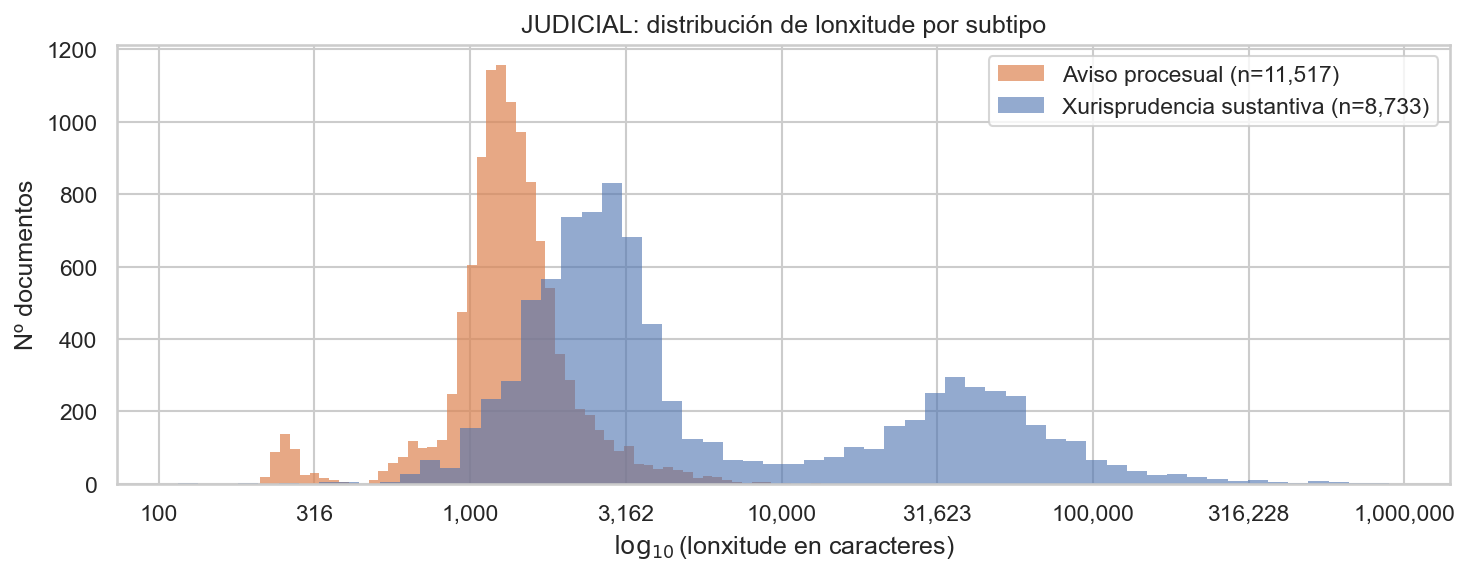

Corte natural entre avisos e sentenzas:
  <  1000 chars:  1937/11517 avisos (17%)  |   225/8736 sustantivos (3%)
  <  2000 chars:  9970/11517 avisos (87%)  |  1994/8736 sustantivos (23%)
  <  3000 chars: 11003/11517 avisos (96%)  |  4096/8736 sustantivos (47%)
  <  5000 chars: 11405/11517 avisos (99%)  |  5629/8736 sustantivos (64%)


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
for subtype, color, alpha in [
    ('Aviso procesual',          '#DD8452', 0.7),
    ('Xurisprudencia sustantiva','#4C72B0', 0.6),
]:
    data = judicial.loc[
        (judicial['subtype'] == subtype) & (judicial['text_len'] > 0), 'text_len'
    ]
    ax.hist(np.log10(data), bins=60, alpha=alpha, color=color,
            label=f'{subtype} (n={len(data):,})', edgecolor='none')

ax.set_xlabel(r'$\log_{10}$(lonxitude en caracteres)')
ax.set_ylabel('Nº documentos')
ax.set_title('JUDICIAL: distribución de lonxitude por subtipo')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{10**x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'eda_judicial_subtypes.pdf')
plt.savefig(FIGURES / 'eda_judicial_subtypes.png')
plt.show()

print('Corte natural entre avisos e sentenzas:')
for thresh in [1000, 2000, 3000, 5000]:
    n_av = (judicial[judicial['subtype']=='Aviso procesual']['text_len'] < thresh).sum()
    n_su = (judicial[judicial['subtype']=='Xurisprudencia sustantiva']['text_len'] < thresh).sum()
    t_av = (judicial['subtype']=='Aviso procesual').sum()
    t_su = (judicial['subtype']=='Xurisprudencia sustantiva').sum()
    print(f'  < {thresh:>5} chars: {n_av:>5}/{t_av} avisos ({n_av/t_av*100:.0f}%)  |  '
          f'{n_su:>4}/{t_su} sustantivos ({n_su/t_su*100:.0f}%)')

## 7. Mostra de texto por familia

Primeiros 400 caracteres dun documento representativo de cada familia (texto xa limpo).

## 8. Clasificación por subtema de PI

Clasificación ortogonal á familia: identifica a materia xurídica de cada documento mediante busca de palabras clave no campo `title`. Compárase coa distribución por familia para escoller o subcorpus de experimentos.

In [14]:
SUBTOPICS = {
    'trade mark':              ['trade mark', 'trademark'],
    'geographical indication': ['geographical indication', 'appellation of origin', 'protected designation'],
    'copyright':               ['copyright', 'related right', 'neighbouring right', 'computer program', 'software'],
    'patent':                  ['patent'],
    'design (industrial)':     ['community design', 'industrial design', 'registered design'],
    'plant variety':           ['plant variety', 'plant breeders'],
    'database right':          ['database', 'sui generis'],
    'trade secret':            ['trade secret', 'know-how'],
    'counterfeiting/piracy':   ['counterfeit', 'piracy', 'pirated'],
    'parallel import':         ['parallel import', 'exhaustion'],
}

In [15]:
df['title_lower'] = df['title'].str.lower()

FAMILIES = ['JUDICIAL', 'LEGISLATIVE', 'POLICY', 'OTHER']

rows = []
for topic, keywords in SUBTOPICS.items():
    mask = df['title_lower'].apply(lambda t: any(k in t for k in keywords))
    sub  = df[mask]
    row  = {'subtema': topic, 'total': len(sub)}
    for fam in FAMILIES:
        row[fam] = (sub['family'] == fam).sum()
    row['% corpus'] = round(len(sub) / len(df) * 100, 1)
    rows.append(row)

topic_df = pd.DataFrame(rows).sort_values('total', ascending=False).reset_index(drop=True)
display(topic_df)
topic_df.to_csv(TABLES / 'subtopic_full.csv', index=False)

,subtema,total,JUDICIAL,LEGISLATIVE,POLICY,OTHER,% corpus
0,trade mark,11249,10293,76,56,824,28.0
1,geographical indication,1331,96,1035,160,40,3.3
2,copyright,656,443,43,106,64,1.6
3,design (industrial),630,584,17,18,11,1.6
4,patent,474,320,35,84,35,1.2
5,counterfeiting/piracy,154,26,14,81,33,0.4
6,plant variety,134,65,32,12,25,0.3
7,parallel import,89,67,1,13,8,0.2
8,database right,56,35,5,5,11,0.1
9,trade secret,21,6,5,7,3,0.1


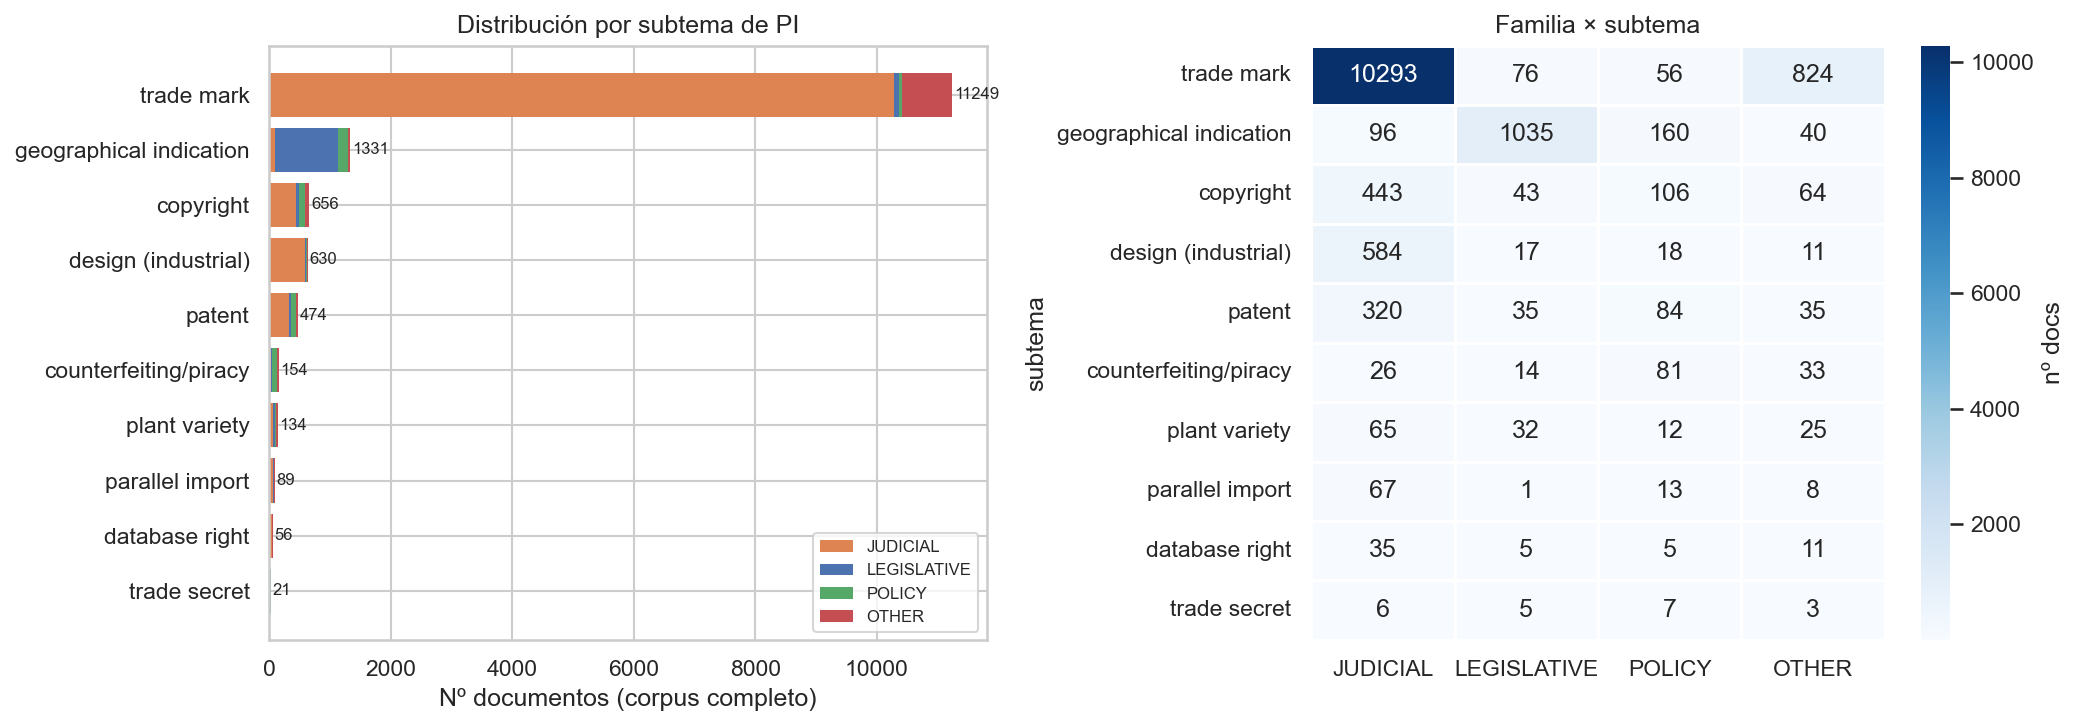

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Esquerda: subtemas como clasificación paralela á familia (corpus completo) —
ax = axes[0]
td = topic_df.sort_values('total')
bottoms = pd.Series([0] * len(td), index=td.index)
for fam in FAMILIES:
    ax.barh(td['subtema'], td[fam], left=bottoms,
            color=FAMILY_COLORS[fam], label=fam, edgecolor='none')
    bottoms = bottoms + td[fam].values
for _, row in td.iterrows():
    ax.text(row['total'] + 30, list(td['subtema']).index(row['subtema']),
            str(row['total']), va='center', fontsize=8)
ax.set_xlabel('Nº documentos (corpus completo)')
ax.set_title('Distribución por subtema de PI')
ax.legend(fontsize=8, loc='lower right')

# — Dereita: heatmap familia × subtema (corpus completo, 4 familias) —
ax2 = axes[1]
heat = topic_df.set_index('subtema')[FAMILIES]
sns.heatmap(heat, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'nº docs'}, ax=ax2)
ax2.set_title('Familia × subtema')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=0)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES / 'eda_subtopics.pdf')
plt.savefig(FIGURES / 'eda_subtopics.png')
plt.show()

In [17]:
for fam in ['LEGISLATIVE', 'JUDICIAL', 'POLICY', 'OTHER']:
    subset = df[(df['family'] == fam) & (df['text_len'] > 2000)]
    if subset.empty:
        subset = df[df['family'] == fam]
    row = subset.sample(1, random_state=42).iloc[0]
    print(f"{'='*60}")
    print(f"FAMILIA : {fam}")
    print(f"Form    : {row['form']}")
    print(f"Data    : {row['date']}")
    print(f"Lonx.   : {row['text_len']:,} chars  (~{row['text_len']//5:,} palabras)")
    print(f"Texto   : {row['text'][:400]}...")
    print()

FAMILIA : LEGISLATIVE
Form    : Regulation
Data    : 27/03/2008
Lonx.   : 35,943 chars  (~7,188 palabras)
Texto   : COMMISSION REGULATION (EC) No 282/2008

of 27 March 2008

on recycled plastic materials and articles intended to come into contact with foods and amending Regulation (EC) No 2023/2006

(Text with EEA relevance)

THE COMMISSION OF THE EUROPEAN COMMUNITIES,

Having regard to the Treaty establishing the European Community,

Having regard to Regulation (EC) No 1935/2004 of the European Parliament and ...

FAMILIA : JUDICIAL
Form    : Judicial information
Data    : 08/09/2014
Lonx.   : 13,057 chars  (~2,611 palabras)
Texto   : Request for a preliminary ruling from the Fővárosi Közigazgatási és Munkaügyi Bíróság (Hungary) lodged on 8 September 2014 — WebMindLicences Kft.Nemzeti Adó és Vámhivatal Kiemelt Adó és Vám Főigazgatóság v Nemzeti Adó és Vámhivatal Kiemelt Adó és Vám Főigazgatóság

(Case C-419/14)

(2014/C 439/25)

Language of the case: Hungarian

Referring court

Főváro